In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

#APPLYING NEW DATASET

In [ ]:
df = pd.read_csv("/content/SAP-4000.csv")

df.head()

,Gender,HoursStudied/Week,Tutoring,Region,Attendance(%),Parent Education,Exam_Score
0,Male,5.5,No,Urban,72.7,Tertiary,43.5
1,Female,6.8,No,Urban,62.0,Primary,51.7
2,Female,9.7,No,Rural,95.0,Secondary,70.1
3,Male,13.3,Yes,Rural,52.9,NaN,79.5
4,Female,8.9,No,Urban,50.8,NaN,52.2


In [ ]:
#sanity check
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,4000,2,Female,2040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HoursStudied/Week,4000.0,NaN,NaN,NaN,9.861025,3.713801,0.0,7.4,9.9,12.6,16.0
Tutoring,4000,2,No,2767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,4000,2,Urban,2423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attendance(%),4000.0,NaN,NaN,NaN,75.22415,14.496906,50.0,62.6,75.6,87.7,100.0
Parent Education,3578,3,Secondary,1590,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Exam_Score,4000.0,NaN,NaN,NaN,71.107775,16.74895,16.6,59.3,71.55,83.5,100.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             4000 non-null   object 
 1   HoursStudied/Week  4000 non-null   float64
 2   Tutoring           4000 non-null   object 
 3   Region             4000 non-null   object 
 4   Attendance(%)      4000 non-null   float64
 5   Parent Education   3578 non-null   object 
 6   Exam_Score         4000 non-null   float64
dtypes: float64(3), object(4)
memory usage: 218.9+ KB


It is observed that Parent education has some missing values. To addes this issue, we will fill the missing values with, "Not-reported"so as to avoid injecting false information in the data and also allowing the models to learn the pattern of this category

In [ ]:
df['Parent Education'].value_counts()

,count
Parent Education,
Secondary,1590
Tertiary,1175
Primary,813


In [ ]:
#filling the miing value and checkig
df["Parent Education"] = (
    df["Parent Education"]
    .fillna("Not-reported")
)

df["Parent Education"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4000 entries, 0 to 3999
Series name: Parent Education
Non-Null Count  Dtype 
--------------  ----- 
4000 non-null   object
dtypes: object(1)
memory usage: 31.4+ KB


**FEATURE ENGINEEING**

In [ ]:
df.columns

Index(['Gender', 'HoursStudied/Week', 'Tutoring', 'Region', 'Attendance(%)',
       'Parent Education', 'Exam_Score'],
      dtype='object')

Text(0.5, 1.0, 'Distribution of Exam Scores to determine threshold')

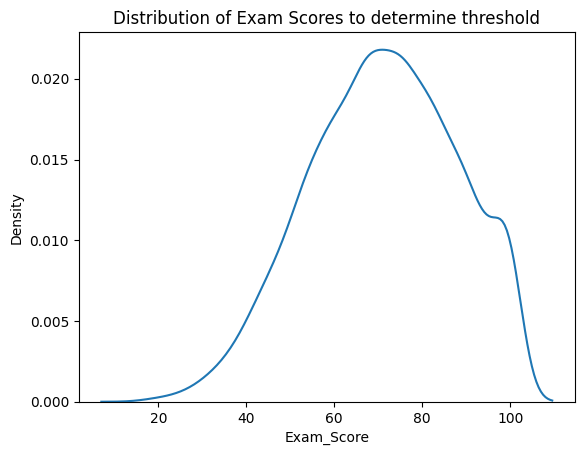

In [ ]:
#Check distribution of exam scores before applying theshold
sns.kdeplot(df["Exam_Score"])
plt.title("Distribution of Exam Scores to determine threshold")

**INSIGHTS FROM THE VISUALIZATION**

From the visualization above, it is gotten that most students have scores around 60 - 80, suggesting that there is a high pass rate- therefore, students with less than the midpoint of these scores (70) should be considered at risk (1) and students above the midpoint (>=70) are not at risk

In [ ]:
#Apply the condition

#Apply the new threshold based on the density plot analysis
# Score < 70 -> At Risk (1)
# Score >= 70 -> Not at Risk (0)
df['at-risk'] = np.where(df['Exam_Score'] < 70, 1, 0)

#check the count of each category
print(df['at-risk'].value_counts())

at-risk
0    2146
1    1854
Name: count, dtype: int64


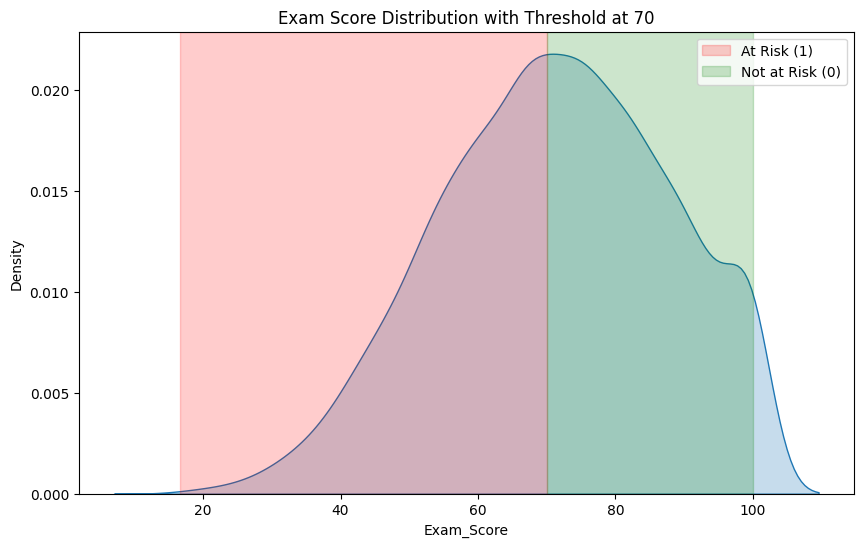

In [ ]:
#visualizing the split

plt.figure(figsize=(10, 6))
sns.kdeplot(df['Exam_Score'], fill=True)

#Shading the 'At-Risk' area (below 70)
plt.axvspan(df['Exam_Score'].min(), 70, color='red', alpha=0.2, label='At Risk (1)')
#Shading the 'Safe' area (above 70)
plt.axvspan(70, df['Exam_Score'].max(), color='green', alpha=0.2, label='Not at Risk (0)')

plt.title('Exam Score Distribution with Threshold at 70')
plt.legend()
plt.show()

Not at Risk (0)-- 2146

**54% are Students performing at or above the class mode**.

At Risk (1) -- 1854

**46% are Students performing below the typical class score**.

#MODEL DEVELOPMENT ON NEW DATA

In [ ]:
df.columns

Index(['Gender', 'HoursStudied/Week', 'Tutoring', 'Region', 'Attendance(%)',
       'Parent Education', 'Exam_Score', 'at-risk'],
      dtype='object')

In [ ]:
#data splitting
y = df["at-risk"]
X = df.drop(columns=["at-risk", "Exam_Score"])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
#data preprocessing

categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
#LOGISTIC REGRESSION
baseline_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

baseline_model.fit(X_train, y_train)

#EVALUATE
y_pred = baseline_model.predict(X_test)

print("--- Logistic Regression Results ---")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


--- Logistic Regression Results ---
[[398  31]
 [ 38 333]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       429
           1       0.91      0.90      0.91       371

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



In [ ]:
#DECISOON TREE

# Define the Decision Tree Pipeline
dt_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

#Fit and Predict
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

#Evaluate
print("--- Decision Tree Results ---")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

--- Decision Tree Results ---
[[374  55]
 [ 43 328]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       429
           1       0.86      0.88      0.87       371

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800



In [ ]:
#RANDOM FOREST

#Define the Random Forest Pipeline
rf_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

#Fit and Predict
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#Evaluate
print("--- Random Forest Results ---")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

--- Random Forest Results ---
[[394  35]
 [ 35 336]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       429
           1       0.91      0.91      0.91       371

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



#COMPARISON ANALYSIS

In [ ]:
#Define a list of our models for easy looping
models = {
    "Logistic Regression": baseline_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

# Dictionary to store the results
results = []

for name, model in models.items():
    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics for the 'At-Risk' class (pos_label=1)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (At-Risk)": precision_score(y_test, y_pred, pos_label=1),
        "Recall (At-Risk)": recall_score(y_test, y_pred, pos_label=1),
        "F1-Score": f1_score(y_test, y_pred, pos_label=1)
    })

# Convert to DataFrame for a clean comparison table
comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.round(3))

                     Accuracy  Precision (At-Risk)  Recall (At-Risk)  F1-Score
Model                                                                         
Logistic Regression     0.914                0.915             0.898     0.906
Decision Tree           0.878                0.856             0.884     0.870
Random Forest           0.912                0.906             0.906     0.906


#MODELS INTEPRETATION

**Overall Performance Summary**
The models performed exceptionally well, with Logistic Regression and Random Forest both achieving over 91% accuracy. This high performance confirms that the features in the dataset (such as attendance or study habits) have a very strong relationship with the 70-point "at-risk" boundary which was established.

**Model-by-Model Breakdown**
1. Logistic Regression (The Precision Leader): This model is the top performer with 91.4% accuracy. It achieved the highest Precision (0.915), meaning it is the most reliable at ensuring that when a student is flagged as "at-risk," they truly belong in that category. It is the best choice if there is limited resources and want to avoid "false alarms."

2. Random Forest (The Safety Net): While slightly behind in total accuracy (91.2%), it tied for the best F1-Score (0.906). It achieved the highest Recall (0.906), making it the most effective model for "catching" struggling students.Choose this model if the priority is ensuring that no student who is actually at risk falls through the cracks undetected.

3. Decision Tree (The Simple Interpreter): This was the weakest model with 87.8% accuracy. Its lower Precision (0.856) suggests it struggles more than the others with "noise" in the data, leading to more incorrect "at-risk" labels.

**Final Recommendation**
1. Use Logistic Regression as the primary model. It is the most mathematically efficient and provided the most accurate segregation for this specific class.

2. Monitor the "False Negatives": Since the Recall is around 0.90, remember that about 10% of at-risk students might still be missed by the algorithm.

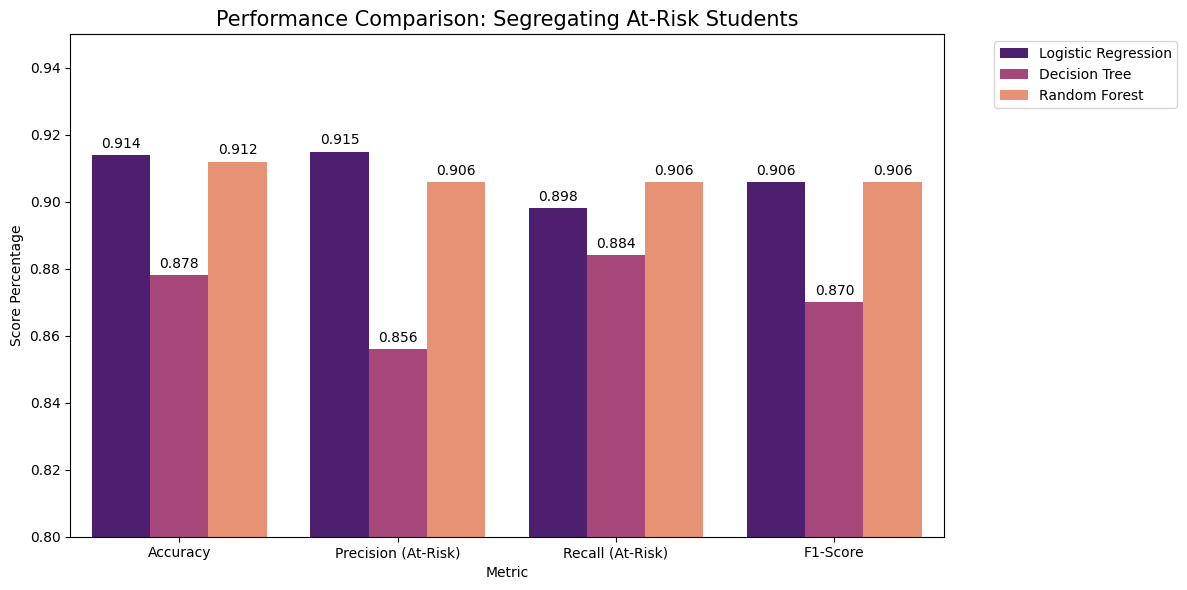

In [ ]:
#VISUAL STORY

#Create the results dataframe
data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.914, 0.878, 0.912],
    "Precision (At-Risk)": [0.915, 0.856, 0.906],
    "Recall (At-Risk)": [0.898, 0.884, 0.906],
    "F1-Score": [0.906, 0.870, 0.906]
}
df_comp = pd.DataFrame(data)

#Melt for Seaborn plotting
df_melted = df_comp.melt(id_vars="Model", var_name="Metric", value_name="Score")

#Create the bar chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="magma")

#Formatting
plt.title("Performance Comparison: Segregating At-Risk Students", fontsize=15)
plt.ylim(0.8, 0.95) # Zoomed in to see differences
plt.ylabel("Score Percentage")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add labels on bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.savefig("model_comparison.png")

**FEATURE IMPORTANCE ANALYSIS**

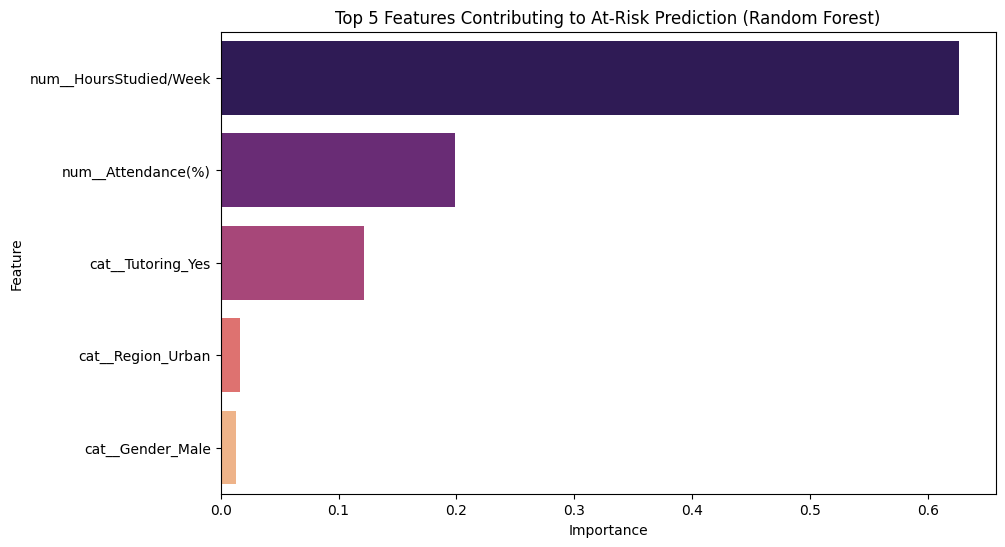

In [ ]:
#Get feature names from the preprocessor
feature_names = rf_model.named_steps['preprocessing'].get_feature_names_out()

#Obtain importances from the model step
importances = rf_model.named_steps['model'].feature_importances_

#Create a DataFrame for visualization
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

#Plot the Top 5 Features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df.head(5), x='Importance', y='Feature', palette='magma')
plt.title('Top 5 Features Contributing to At-Risk Prediction (Random Forest)')
plt.show()

**WHAT IT SUGGESTS**

The bar chart identifies exactly what is driving the models' high accuracy (91%+) in predicting who will fall into the "at-risk" category.

1. Hours Studied per Week: This is the dominant predictor by a significant margin (Importance > 0.6). It suggests that time spent on task is the single most critical factor in staying above the 70-point threshold.

2. Attendance (%): Coming in second (Importance ~0.2), attendance acts as a secondary "safety net." Consistent presence in class strongly correlates with being "not at risk."

3. Tutoring: Having access to tutoring is the third most important feature. This suggests that external support is a measurable differentiator for student success in this group.

4. Features like Region (Urban) and Gender (Male) have very low importance scores. This is a positive finding, as it implies that student success is being driven more by controllable behaviors (studying and attendance) rather than demographic traits.

**Logistic Regression Weights**

In [ ]:
#Get coefficients from Logistic Regression
coefficients = baseline_model.named_steps['model'].coef_[0]
coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

print(coeff_df.head(5)) # Features that most strongly predict being AT-RISK

                           Feature  Coefficient
2                 cat__Gender_Male     0.752896
5    cat__Parent Education_Primary    -0.519659
6  cat__Parent Education_Secondary    -1.015093
4                cat__Region_Urban    -1.077446
1               num__Attendance(%)    -1.435023


**INTERPRETING THE DIRECTION OF FEATURES USING LOGISTIC REGRESSION**

1. Gender (Male): Being male has a positive coefficient (0.75), meaning in this specific dataset, male students have a higher probability of being classified as at-risk compared to the baseline.

2. Attendance: This is the strongest protective factor (-1.43). As attendance percentages go up, the probability of being at-risk drops significantly.

3. Urban Environment: Living in an Urban region (-1.07) is associated with a lower risk of falling below the 70-point threshold compared to other regions.

4. Parental Education: Both Secondary (-1.01) and Primary (-0.51) education levels have negative coefficients, suggesting that as parental education levels increase (from primary to secondary), the risk to the student decreases.

#OVERALL SUMMARY AND FULL STEPS

**Data Segregation Strategy**

1. The Threshold: Based on the density plot showing a peak performance around 70, we shifted the "at-risk" definition from a failing grade ( less than 40) to a performance-based midpoint (less than 70).

2. Class Balance: This adjustment successfully addressed class imbalance, resulting in a nearly even split: 2,146 safe students vs. 1,854 at-risk students.

**Model Performance Comparison**
1. Top Performer: Logistic Regression achieved the highest overall accuracy (0.914) and precision (0.915), making it the most reliable model for accurate classification.

2. The Safety Net: Random Forest tied for the best F1-Score (0.906) and offered the highest recall (0.906), ensuring the fewest at-risk students are missed.

3. Consistency: All models performed exceptionally well (above 87% accuracy), proving that the "at-risk" status is highly predictable based on the features provided.

**Key Predictors of Risk**
The models identified that student risk is driven by a combination of effort, attendance, and environment:

1. The Primary Drivers (Behavioral):
  a. Study Hours: The #1 predictor; more time spent studying is the strongest shield against being at-risk.
  b. Attendance: High attendance acts as a significant "protective factor" (indicated by its strong negative coefficient of -1.43).
  
2. The Secondary Factors (Contextual)
  a. Demographics: Being Male increases the statistical probability of being at-risk in this specific class (coefficient: +0.75).
  b. Support & Environment: Tutoring access, Urban residency, and higher Parental Education levels all significantly reduce the likelihood of a student being flagged as at-risk.
  
**Final Conclusion**
The segregation of this class is highly successful. By focusing interventions on increasing study hours and improving attendance, especially for male students or those without tutoring support, you can most effectively move students from the "at-risk" category to the "safe" category.

**ERROR ANALYSIS**

In [ ]:
y_pred_series = pd.Series(y_pred, index=X_test.index)

misclassified_students = pd.concat([X_test.reset_index(drop=True),
                                    y_test.reset_index(drop=True).rename('Actual'),
                                    y_pred_series.reset_index(drop=True).rename('Predicted')],
                                   axis=1)

false_positives = misclassified_students[(misclassified_students['Actual'] == 0) & (misclassified_students['Predicted'] == 1)]
false_negatives = misclassified_students[(misclassified_students['Actual'] == 1) & (misclassified_students['Predicted'] == 0)]

print("False Positives:")
print(false_positives.head())
print("\nFalse Negatives:")
print(false_negatives.head())

False Positives:
     Gender  HoursStudied/Week Tutoring Region  Attendance(%)  \
14   Female                8.2      Yes  Urban           50.1   
32     Male                4.1      Yes  Rural           92.0   
63     Male               11.4       No  Urban           59.6   
113  Female               10.8       No  Urban           60.5   
121    Male                6.6      Yes  Rural           96.5   

    Parent Education  Actual  Predicted  
14         Secondary       0          1  
32          Tertiary       0          1  
63          Tertiary       0          1  
113        Secondary       0          1  
121     Not-reported       0          1  

False Negatives:
    Gender  HoursStudied/Week Tutoring Region  Attendance(%) Parent Education  \
52    Male                9.4       No  Urban           91.4         Tertiary   
61    Male               11.5       No  Urban           86.0          Primary   
73    Male                7.4      Yes  Urban           73.1          Primary  


Now that false positives and false negatives have been identified, the next step is to analyze their characteristics, such as average hours studied, attendance, parent education, and gender, to understand common patterns in misclassification.



In [ ]:
print("\n--- False Positives Characteristics ---")
print(false_positives[['HoursStudied/Week', 'Attendance(%)']].mean())
print(false_positives['Gender'].value_counts(normalize=True))
print(false_positives['Parent Education'].value_counts(normalize=True))

print("\n--- False Negatives Characteristics ---")
print(false_negatives[['HoursStudied/Week', 'Attendance(%)']].mean())
print(false_negatives['Gender'].value_counts(normalize=True))
print(false_negatives['Parent Education'].value_counts(normalize=True))


--- False Positives Characteristics ---
HoursStudied/Week     9.017143
Attendance(%)        73.957143
dtype: float64
Gender
Male      0.514286
Female    0.485714
Name: proportion, dtype: float64
Parent Education
Secondary       0.542857
Tertiary        0.200000
Primary         0.200000
Not-reported    0.057143
Name: proportion, dtype: float64

--- False Negatives Characteristics ---
HoursStudied/Week    10.422857
Attendance(%)        74.505714
dtype: float64
Gender
Female    0.542857
Male      0.457143
Name: proportion, dtype: float64
Parent Education
Secondary       0.400000
Primary         0.285714
Tertiary        0.228571
Not-reported    0.085714
Name: proportion, dtype: float64


### Educational Implications of Error Analysis

**False Positives (Predicted At-Risk, Actual Not At-Risk)**
These are students who the model incorrectly flagged as 'at-risk' when they were actually 'not at-risk'.

*   **Characteristics from Analysis:**
    *   **Hours Studied:** Mean of 9.02 hours/week, which is slightly lower than false negatives but still reasonably high.
    *   **Attendance:** Mean of 73.96%, close to the overall average.
    *   **Gender:** Roughly even split between Male (51.4%) and Female (48.6%).
    *   **Parent Education:** High proportion with Secondary education (54.3%), suggesting varied educational backgrounds.

*   **Implication:** False positives represent students who might be unnecessarily targeted for intervention. While their metrics (like study hours) might be on the lower side of the 'not at-risk' group, they still perform adequately. Over-identification can lead to wasted resources and potentially stigmatize students who are actually doing fine. These students might have other uncaptured strengths or receive support that isn't explicitly in the model.

**False Negatives (Predicted Not At-Risk, Actual At-Risk)**
These are students who the model incorrectly identified as 'not at-risk' when they were actually 'at-risk'.

*   **Characteristics from Analysis:**
    *   **Hours Studied:** Mean of 10.42 hours/week, which is higher than the false positives. This is a critical insight, suggesting some at-risk students are studying a fair amount, but it's not translating to scores above 70.
    *   **Attendance:** Mean of 74.51%, also close to the overall average.
    *   **Gender:** Higher proportion of Female students (54.3%) compared to Male (45.7%).
    *   **Parent Education:** Similar distribution to false positives, with Secondary being the largest group (40%).

*   **Implication:** False negatives are concerning because these are the students who genuinely need support but are missed by the system. The higher average 'Hours Studied/Week' for false negatives suggests that *quantity* of study might not always equate to *quality* or *effectiveness*. These students might be struggling with comprehension, study techniques, or have learning disabilities that aren't addressed by simply putting in hours or attending classes. They are at risk of falling further behind if not identified and supported.

**Overall Educational Interventions:**

1.  **Refine Intervention for False Positives:** For students identified as false positives, a lighter-touch approach might be better. Instead of intensive intervention, perhaps offer optional workshops on advanced study skills or stress management, allowing them to opt-in if they feel a need.

2.  **Targeted Support for False Negatives:** Given that false negatives tend to study a reasonable amount, interventions should focus on the *effectiveness* of their study rather than just the *amount*. This could include:
    *   **Personalized Learning Plans:** Tailored strategies to address specific learning gaps.
    *   **Academic Coaching:** Help with active learning, note-taking, and critical thinking skills.
    *   **Diagnostic Assessments:** To identify underlying learning difficulties or gaps in foundational knowledge.
    *   **Teacher Training:** Equip educators to identify subtle signs of struggle in students who appear to be engaging (e.g., attending class, studying hours) but are not performing well.

3.  **Holistic Student Profile:** The model, while effective, might benefit from additional features that capture qualitative aspects of learning, such as engagement in class, participation, or feedback from teachers, to better differentiate between effective and ineffective study habits.

### Educational Implications of Error Analysis

**False Positives (Predicted At-Risk, Actual Not At-Risk)**
These are students who the model incorrectly flagged as 'at-risk' when they were actually 'not at-risk'.

*   **Characteristics from Analysis:**
    *   **Hours Studied:** Mean of 9.02 hours/week, which is slightly lower than false negatives but still reasonably high.
    *   **Attendance:** Mean of 73.96%, close to the overall average.
    *   **Gender:** Roughly even split between Male (51.4%) and Female (48.6%).
    *   **Parent Education:** High proportion with Secondary education (54.3%), suggesting varied educational backgrounds.

*   **Implication:** False positives represent students who might be unnecessarily targeted for intervention. While their metrics (like study hours) might be on the lower side of the 'not at-risk' group, they still perform adequately. Over-identification can lead to wasted resources and potentially stigmatize students who are actually doing fine. These students might have other uncaptured strengths or receive support that isn't explicitly in the model.

**False Negatives (Predicted Not At-Risk, Actual At-Risk)**
These are students who the model incorrectly identified as 'not at-risk' when they were actually 'at-risk'.

*   **Characteristics from Analysis:**
    *   **Hours Studied:** Mean of 10.42 hours/week, which is higher than the false positives. This is a critical insight, suggesting some at-risk students are studying a fair amount, but it's not translating to scores above 70.
    *   **Attendance:** Mean of 74.51%, also close to the overall average.
    *   **Gender:** Higher proportion of Female students (54.3%) compared to Male (45.7%).
    *   **Parent Education:** Similar distribution to false positives, with Secondary being the largest group (40%).

*   **Implication:** False negatives are concerning because these are the students who genuinely need support but are missed by the system. The higher average 'Hours Studied/Week' for false negatives suggests that *quantity* of study might not always equate to *quality* or *effectiveness*. These students might be struggling with comprehension, study techniques, or have learning disabilities that aren't addressed by simply putting in hours or attending classes. They are at risk of falling further behind if not identified and supported.

**Overall Educational Interventions:**

1.  **Refine Intervention for False Positives:** For students identified as false positives, a lighter-touch approach might be better. Instead of intensive intervention, perhaps offer optional workshops on advanced study skills or stress management, allowing them to opt-in if they feel a need.

2.  **Targeted Support for False Negatives:** Given that false negatives tend to study a reasonable amount, interventions should focus on the *effectiveness* of their study rather than just the *amount*. This could include:
    *   **Personalized Learning Plans:** Tailored strategies to address specific learning gaps.
    *   **Academic Coaching:** Help with active learning, note-taking, and critical thinking skills.
    *   **Diagnostic Assessments:** To identify underlying learning difficulties or gaps in foundational knowledge.
    *   **Teacher Training:** Equip educators to identify subtle signs of struggle in students who appear to be engaging (e.g., attending class, studying hours) but are not performing well.

3.  **Holistic Student Profile:** The model, while effective, might benefit from additional features that capture qualitative aspects of learning, such as engagement in class, participation, or feedback from teachers, to better differentiate between effective and ineffective study habits.

## Summary:

### Q&A
The error analysis of the `baseline_model`'s misclassifications reveals distinct characteristics between false positives and false negatives, leading to specific educational implications:

*   **False Positives (Predicted At-Risk, Actual Not At-Risk):** These students were incorrectly flagged as at-risk. They showed a mean of 9.02 hours studied/week and 73.96% attendance. Gender was roughly split (51.4% Male, 48.6% Female), and 54.3% had parents with secondary education. The implication is that targeting these students with intensive interventions would be a misallocation of resources and could potentially stigmatize students who are performing adequately.
*   **False Negatives (Predicted Not At-Risk, Actual At-Risk):** These students were incorrectly identified as not at-risk, despite actually needing support. They exhibited a higher mean of 10.42 hours studied/week and 74.51% attendance. There was a slightly higher proportion of female students (54.3%) compared to male (45.7%), and 40% had parents with secondary education. The critical insight here is that the quantity of study hours does not always translate to effective learning or success, suggesting these students may struggle with comprehension, study techniques, or have unaddressed learning difficulties.

### Data Analysis Key Findings
*   **False Positives' Characteristics:** Students misclassified as at-risk but performing adequately studied an average of 9.02 hours/week and had an average attendance of 73.96%. The gender distribution was nearly even (51.4% Male, 48.6% Female), and 54.3% of their parents had a secondary education.
*   **False Negatives' Characteristics:** Students who were truly at-risk but missed by the model studied a higher average of 10.42 hours/week and had a similar average attendance of 74.51%. There was a slightly higher proportion of females (54.3%) among false negatives, and 40% of their parents had a secondary education.
*   **Key Distinction in Study Hours:** False negatives, despite being at-risk, reported studying more hours on average (10.42 hours/week) than false positives (9.02 hours/week), indicating that study effort alone is not a sufficient predictor of success for some students.

### Insights or Next Steps
*   **Refine Intervention Strategies:** For false positives, implement lighter-touch interventions such as optional workshops rather than intensive support to avoid resource misallocation and student stigmatization.
*   **Targeted Support for False Negatives:** Interventions for false negatives should focus on the *effectiveness* of study rather than just the *amount*, potentially through personalized learning plans, academic coaching, diagnostic assessments for learning difficulties, and enhanced teacher training to identify subtle signs of struggle.
